In [49]:
%pip install matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 9.2 MB/s eta 0:00:01
   ------ --------------------------------- 1.6/9.5 MB 7.3 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.5 MB 4.9 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.5 MB 4.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 4.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 3.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 3.4 MB/s eta 0:00:02
   ----------------- ---------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## 1. Data Preprocessing

Load the dataset and separate the input features (Outlook, Temperature, Humidity, Wind) from the target variable (Play).

In [61]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [26]:
df = pd.read_csv("Tennis.csv")

In [27]:
df = df.drop(columns = ["No"])

In [28]:
df.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [29]:
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = df['Play Tennis']

In [30]:
le = LabelEncoder()

In [31]:
X_encoded = X.copy()
for column in X.columns:
    X_encoded[column] = le.fit_transform(X[column])

In [32]:
y_encoded = le.fit_transform(y)

In [33]:
print("Encoded Features:")
print(X_encoded)

print("Encoded Target:")
print(y_encoded)

Encoded Features:
    Outlook  Temperature  Humidity  Wind
0         2            1         0     1
1         2            1         0     0
2         0            1         0     1
3         1            2         0     1
4         1            0         1     1
5         1            0         1     0
6         0            0         1     0
7         2            2         0     1
8         2            0         1     1
9         1            2         1     1
10        2            2         1     0
11        0            2         0     0
12        0            1         1     1
13        1            2         0     0
14        2            0         0     1
15        2            0         0     0
16        2            1         1     1
17        2            1         1     0
18        0            0         0     1
19        0            0         0     0
20        0            2         1     1
21        0            2         1     0
22        1            1         0     

In [34]:
for column in df.columns:
    le.fit(df[column])

    print(f"{column} Mapping:")
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(mapping)

Outlook Mapping:
{'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
Temperature Mapping:
{'Cool': np.int64(0), 'Hot': np.int64(1), 'Mild': np.int64(2)}
Humidity Mapping:
{'High': np.int64(0), 'Normal': np.int64(1)}
Wind Mapping:
{'Strong': np.int64(0), 'Weak': np.int64(1)}
Play Tennis Mapping:
{'No': np.int64(0), 'Yes': np.int64(1)}


## 2. Dataset Partitioning:

Divide the dataset into training and testing subsets using an 80:20 train-test split ratio.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size = 0.2, random_state = 42)

In [37]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (40, 4)
Testing Features Shape: (10, 4)
Training Target Shape: (40,)
Testing Target Shape: (10,)


## 3. Naive Bayes Model Training & Evaluation:

Train a Categorical Naive Bayes (CategoricalNB) model on the training data.

In [39]:
model = CategoricalNB()

In [40]:
model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 0., ...., 8., 5.]]), array([[ 6., ...., 8., 12.]]), array([[13., ... [ 9., 17.]]), array([[ 9., ... [ 8., 18.]])]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[14.,26.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-1.05,-0.43]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.83...-1.57553636]]), array([[-0.88...-0.80234647]]), array([[-0.13...-0.44183275]]), array([[-0.47...-0.38776553]])]"


Predict the class labels for the test dataset.

In [41]:
y_pred = model.predict(X_test)

Calculate and display the overall Model Accuracy.

In [42]:
accuracy = accuracy_score(y_test, y_pred)

In [43]:
print("Actual Labels   :", y_test)
print("Predicted Labels:", y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Actual Labels   : [0 1 1 1 1 1 1 0 1 1]
Predicted Labels: [0 1 1 1 1 1 0 1 1 1]
Model Accuracy: 0.80
Model Accuracy: 80.00%


Display the Confusion Matrix and Classification Report (Precision, Recall, F1-Score).

In [45]:
cm = confusion_matrix(y_test, y_pred)

In [46]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 1]
 [1 7]]


In [47]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10



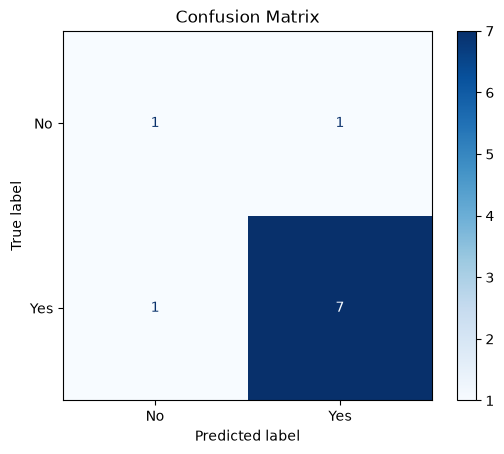

In [52]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = ["No", "Yes"], cmap = "Blues")

plt.title("Confusion Matrix")
plt.show()

## 4. Single-Sample Inference:

Predict whether a person will play tennis under the following specific weather conditions:
- Outlook: Sunny
- Temperature: Cool
- Humidity: High
- Wind: Strong


In [53]:
new_sample = [[2, 0, 0, 0]]

In [ ]:
prediction = model.predict(new_sample)

C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


In [55]:
probabilities = model.predict_proba(new_sample)

C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


In [59]:
labels = ["No", "Yes"]

print("Weather Conditions:")
print("Outlook     : Sunny")
print("Temperature : Cool")
print("Humidity    : High")
print("Wind        : Strong")

Weather Conditions:
Outlook     : Sunny
Temperature : Cool
Humidity    : High
Wind        : Strong


Display both the predicted class label and the corresponding class probabilities.

In [60]:
print("Predicted Class:", labels[prediction[0]])
print()
print("Class Probabilities:")
print(f"No  : {probabilities[0][0]:.4f}")
print(f"Yes : {probabilities[0][1]:.4f}")

Predicted Class: No

Class Probabilities:
No  : 0.9256
Yes : 0.0744


## 5. Model Comparison:

In [62]:
dt_model = DecisionTreeClassifier(random_state = 42)
lr_model = LogisticRegression(random_state = 42)
svm_model = SVC(kernel = 'rbf', probability = True, random_state = 42)

In [63]:
models = {
    "Decision Tree": dt_model,
    "Logistic Regression": lr_model,
    "SVM": svm_model
}

In [64]:
new_sample = [[2, 0, 0, 0]]

In [65]:
labels = ["No", "Yes"]

In [66]:
results = []

In [67]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    sample_pred = model.predict(new_sample)[0]
    probs = model.predict_proba(new_sample)[0]
    results.append({
        "Model": name,
        "Test Accuracy": f"{accuracy*100:.2f}%",
        "Prediction": labels[sample_pred],
        "P(No)": round(probs[0], 4),
        "P(Yes)": round(probs[1], 4)
    })

C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_bas

In [68]:
comparison = pd.DataFrame(results)
print(comparison)

                 Model Test Accuracy Prediction   P(No)  P(Yes)
0        Decision Tree        80.00%         No  1.0000  0.0000
1  Logistic Regression        40.00%         No  0.9439  0.0561
2                  SVM        70.00%         No  0.9751  0.0249


Interpretation
1. Decision Tree
- Achieved the highest test accuracy (80%).
- Predicted "No" with complete confidence (100% probability).
- On a small dataset like Play Tennis, Decision Trees often produce probabilities of 0 or 1 because each leaf may contain only one class.

2. Logistic Regression
- Achieved the lowest test accuracy (40%).
- Predicted "No" with a probability of 94.39%.
- Logistic Regression assumes a linear decision boundary, which may not model this small categorical dataset as effectively.

3. SVM
- Achieved 70% test accuracy.
- Predicted "No" with a probability of 97.51%.
- SVM generally performs well on classification tasks, but its probability estimates are obtained through calibration and may not directly reflect the margin.